# Accuracy by Task Difficulty

This notebook analyzes how task difficulty relates to model performance across the five ARC experiment settings. It loads experiment results, joins difficulty labels, computes task-level and example-level accuracy summaries, saves CSV outputs, and displays grouped bar charts by difficulty.


## 1. Setup

In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image as DisplayImage, display


def resolve_project_root() -> Path:
    """Walk upward from cwd until we find a directory that contains final_outputs/."""
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "final_outputs").is_dir():
            return candidate
        # Legacy layout: sample/final_outputs under the repo
        legacy = candidate / "sample" / "final_outputs"
        if legacy.is_dir():
            return candidate / "sample"
    raise FileNotFoundError(
        "Could not locate experiment outputs. Expected a `final_outputs` directory "
        "(at the project root or under `sample/`). Unzip `final_outputs.zip` if needed, "
        "and run the notebook with the working directory inside the repo (e.g. open "
        "the project folder in Cursor/Jupyter)."
    )


ROOT = resolve_project_root()
print(f"Project root: {ROOT}")


Project root: /Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation


## 2. Helper functions

This section defines the data-loading, metric-computation, CSV-writing, and plotting functions used in the analysis below.


In [14]:
import csv
from collections import defaultdict
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt


# ROOT is defined in the setup cell.
FINAL_OUTPUTS = ROOT / "final_outputs"
DIFFICULTY_FILE = ROOT / "data" / "task_data" / "train_hints_with_difficulty.csv"
OUTPUT_DIR = ROOT / "analysis_outputs"

EXPERIMENTS = [
    ("0_output_grid", "Direct Output Grid", "output_grid_top1"),
    ("1_program_only", "Program Only", "program_only_best"),
    ("2_hypo_program", "Hypothesis + Program", "selected_examples"),
    ("3_hint_hypo_program", "Hint + Hypothesis + Program", "selected_examples"),
    ("4_good_hypo_program", "High Quality Hypothesis + Program", "selected_examples"),
]

DIFFICULTY_ORDER = ["Easy", "Medium", "Hard", "Expert"]
EXPERIMENT_COLORS = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#B07AA1"]


def read_csv(path: Path) -> list[dict[str, str]]:
    with path.open("r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))


def bool_value(value: Any) -> bool:
    return str(value).strip().lower() in {"true", "1", "yes", "y"}


def int_value(value: Any, default: int = 0) -> int:
    try:
        if value is None or value == "":
            return default
        return int(float(str(value)))
    except ValueError:
        return default


def load_task_difficulties() -> dict[str, str]:
    rows = read_csv(DIFFICULTY_FILE)
    return {row["task_id"]: row["difficulty"] for row in rows}


def init_task_records(
    experiment_order: int,
    experiment_folder: str,
    experiment_name: str,
    task_difficulties: dict[str, str],
) -> dict[str, dict[str, Any]]:
    return {
        task_id: {
            "experiment_order": experiment_order,
            "experiment_folder": experiment_folder,
            "experiment_name": experiment_name,
            "task_id": task_id,
            "difficulty": difficulty,
            "test_examples": 0,
            "correct_test_examples": 0,
            "task_correct": False,
        }
        for task_id, difficulty in task_difficulties.items()
    }


def selected_output_grid_records(
    rows: list[dict[str, str]],
    base_records: dict[str, dict[str, Any]],
) -> dict[str, dict[str, Any]]:
    """Use only top-1 generated output-grid rows, matching the readme metric."""
    for row in rows:
        if not bool_value(row.get("is_top1")):
            continue
        task_id = row["task_id"]
        record = base_records.setdefault(
            task_id,
            {
                "task_id": task_id,
                "difficulty": row.get("difficulty", "Unknown"),
                "test_examples": 0,
                "correct_test_examples": 0,
                "task_correct": False,
            },
        )
        record["test_examples"] += 1
        record["correct_test_examples"] += int(bool_value(row.get("correct")))

    for record in base_records.values():
        record["task_correct"] = (
            record["test_examples"] > 0
            and record["correct_test_examples"] == record["test_examples"]
        )
    return base_records


def selected_program_only_records(
    rows: list[dict[str, str]],
    base_records: dict[str, dict[str, Any]],
) -> dict[str, dict[str, Any]]:
    """Use the selected best program row, matching the readme metric."""
    for row in rows:
        if not bool_value(row.get("is_best")):
            continue
        task_id = row["task_id"]
        record = base_records.setdefault(
            task_id,
            {
                "task_id": task_id,
                "difficulty": row.get("difficulty", "Unknown"),
                "test_examples": 0,
                "correct_test_examples": 0,
                "task_correct": False,
            },
        )
        record["test_examples"] = int_value(row.get("test_total_examples"))
        record["correct_test_examples"] = int_value(row.get("test_correct_count"))
        record["task_correct"] = bool_value(row.get("test_pass_all"))
    return base_records


def selected_example_records(
    rows: list[dict[str, str]],
    base_records: dict[str, dict[str, Any]],
) -> dict[str, dict[str, Any]]:
    """Rows are already the selected program's predictions on test examples."""
    for row in rows:
        task_id = row["task_id"]
        record = base_records.setdefault(
            task_id,
            {
                "task_id": task_id,
                "difficulty": row.get("difficulty", "Unknown"),
                "test_examples": 0,
                "correct_test_examples": 0,
                "task_correct": False,
            },
        )
        record["test_examples"] += 1
        record["correct_test_examples"] += int(bool_value(row.get("correct")))

    for record in base_records.values():
        record["task_correct"] = (
            record["test_examples"] > 0
            and record["correct_test_examples"] == record["test_examples"]
        )
    return base_records


def collect_task_records(task_difficulties: dict[str, str]) -> list[dict[str, Any]]:
    all_records: list[dict[str, Any]] = []
    builders = {
        "output_grid_top1": selected_output_grid_records,
        "program_only_best": selected_program_only_records,
        "selected_examples": selected_example_records,
    }

    for experiment_order, (folder, name, kind) in enumerate(EXPERIMENTS):
        rows = read_csv(FINAL_OUTPUTS / folder / "results.csv")
        base_records = init_task_records(
            experiment_order, folder, name, task_difficulties
        )
        records = builders[kind](rows, base_records)
        for record in records.values():
            total = record["test_examples"]
            record["task_correct"] = bool(record["task_correct"])
            record["example_accuracy"] = (
                record["correct_test_examples"] / total if total else 0.0
            )
            all_records.append(record)

    return sorted(
        all_records,
        key=lambda row: (
            row["experiment_order"],
            DIFFICULTY_ORDER.index(row["difficulty"])
            if row["difficulty"] in DIFFICULTY_ORDER
            else len(DIFFICULTY_ORDER),
            row["task_id"],
        ),
    )


def summarize(records: list[dict[str, Any]]) -> list[dict[str, Any]]:
    grouped: dict[tuple[int, str], dict[str, Any]] = {}

    for row in records:
        key = (row["experiment_order"], row["difficulty"])
        if key not in grouped:
            grouped[key] = {
                "experiment_order": row["experiment_order"],
                "experiment_folder": row["experiment_folder"],
                "experiment_name": row["experiment_name"],
                "difficulty": row["difficulty"],
                "task_count": 0,
                "solved_tasks": 0,
                "test_examples": 0,
                "correct_test_examples": 0,
            }
        item = grouped[key]
        item["task_count"] += 1
        item["solved_tasks"] += int(row["task_correct"])
        item["test_examples"] += row["test_examples"]
        item["correct_test_examples"] += row["correct_test_examples"]

    summary = []
    for item in grouped.values():
        item["task_accuracy"] = (
            item["solved_tasks"] / item["task_count"] if item["task_count"] else 0.0
        )
        item["example_accuracy"] = (
            item["correct_test_examples"] / item["test_examples"]
            if item["test_examples"]
            else 0.0
        )
        item["task_accuracy_pct"] = round(item["task_accuracy"] * 100, 2)
        item["example_accuracy_pct"] = round(item["example_accuracy"] * 100, 2)
        summary.append(item)

    return sorted(
        summary,
        key=lambda row: (
            row["experiment_order"],
            DIFFICULTY_ORDER.index(row["difficulty"])
            if row["difficulty"] in DIFFICULTY_ORDER
            else len(DIFFICULTY_ORDER),
        ),
    )


def write_csv(path: Path, rows: list[dict[str, Any]], fieldnames: list[str]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(rows)


def plot_grouped_bars(
    summary: list[dict[str, Any]],
    metric: str,
    ylabel: str,
    title: str,
    output_path: Path,
) -> None:
    task_counts = {
        row["difficulty"]: row["task_count"]
        for row in summary
        if row["experiment_order"] == 0
    }
    difficulties = [d for d in DIFFICULTY_ORDER if d in task_counts]
    experiments = [(folder, name) for folder, name, _ in EXPERIMENTS]
    lookup = {
        (row["experiment_folder"], row["difficulty"]): row[metric]
        for row in summary
    }

    x_positions = list(range(len(difficulties)))
    bar_width = 0.15
    fig, ax = plt.subplots(figsize=(12, 6))

    for exp_index, (folder, name) in enumerate(experiments):
        offset = (exp_index - (len(experiments) - 1) / 2) * bar_width
        values = [lookup.get((folder, difficulty), 0.0) * 100 for difficulty in difficulties]
        bars = ax.bar(
            [x + offset for x in x_positions],
            values,
            width=bar_width,
            label=name,
            color=EXPERIMENT_COLORS[exp_index],
        )
        ax.bar_label(bars, labels=[f"{value:.0f}%" for value in values], fontsize=8)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 105)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        [f"{difficulty}\n(n={task_counts[difficulty]})" for difficulty in difficulties]
    )
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=200)
    plt.close(fig)


def print_summary(summary: list[dict[str, Any]]) -> None:
    print("Task accuracy by difficulty:")
    for row in summary:
        print(
            f"- {row['experiment_folder']} | {row['difficulty']}: "
            f"{row['solved_tasks']}/{row['task_count']} "
            f"({row['task_accuracy_pct']:.2f}%)"
        )


def main() -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    task_difficulties = load_task_difficulties()
    records = collect_task_records(task_difficulties)
    summary = summarize(records)

    task_fields = [
        "experiment_order",
        "experiment_folder",
        "experiment_name",
        "task_id",
        "difficulty",
        "test_examples",
        "correct_test_examples",
        "example_accuracy",
        "task_correct",
    ]
    summary_fields = [
        "experiment_order",
        "experiment_folder",
        "experiment_name",
        "difficulty",
        "task_count",
        "solved_tasks",
        "task_accuracy",
        "task_accuracy_pct",
        "test_examples",
        "correct_test_examples",
        "example_accuracy",
        "example_accuracy_pct",
    ]

    write_csv(OUTPUT_DIR / "task_outcomes_by_experiment.csv", records, task_fields)
    write_csv(OUTPUT_DIR / "difficulty_accuracy_summary.csv", summary, summary_fields)
    plot_grouped_bars(
        summary,
        metric="task_accuracy",
        ylabel="Task accuracy (%)",
        title="Task Accuracy by Difficulty Across Experiments",
        output_path=OUTPUT_DIR / "task_accuracy_by_difficulty.png",
    )
    plot_grouped_bars(
        summary,
        metric="example_accuracy",
        ylabel="Test example accuracy (%)",
        title="Test Example Accuracy by Difficulty Across Experiments",
        output_path=OUTPUT_DIR / "example_accuracy_by_difficulty.png",
    )

    print_summary(summary)
    print(f"\nWrote outputs to: {OUTPUT_DIR}")


## 3. Load difficulty labels and raw experiment files

In [15]:
task_difficulties = load_task_difficulties()
raw_counts = []
for folder, name, kind in EXPERIMENTS:
    rows = read_csv(FINAL_OUTPUTS / folder / "results.csv")
    raw_counts.append({"folder": folder, "experiment": name, "record_type": kind, "raw_rows": len(rows)})

print(f"Difficulty labels: {len(task_difficulties)} tasks")
display(pd.Series(task_difficulties).value_counts().rename_axis("difficulty").reset_index(name="task_count"))
display(pd.DataFrame(raw_counts))

Difficulty labels: 100 tasks


,difficulty,task_count
0,Easy,62
1,Medium,25
2,Hard,9
3,Expert,4


,folder,experiment,record_type,raw_rows
0,0_output_grid,Direct Output Grid,output_grid_top1,629
1,1_program_only,Program Only,program_only_best,600
2,2_hypo_program,Hypothesis + Program,selected_examples,105
3,3_hint_hypo_program,Hint + Hypothesis + Program,selected_examples,105
4,4_good_hypo_program,High Quality Hypothesis + Program,selected_examples,105


## 4. Build one task-level outcome row per experiment

In [16]:
records = collect_task_records(task_difficulties)
task_outcomes = pd.DataFrame(records)
print(task_outcomes.shape)
display(task_outcomes.head(10))
display(task_outcomes.groupby("experiment_name").agg(tasks=("task_id", "count"), solved=("task_correct", "sum")))

(500, 9)


,experiment_order,experiment_folder,experiment_name,task_id,difficulty,test_examples,correct_test_examples,task_correct,example_accuracy
0,0,0_output_grid,Direct Output Grid,025d127b,Easy,1,1,True,1.0
1,0,0_output_grid,Direct Output Grid,0a938d79,Easy,1,0,False,0.0
2,0,0_output_grid,Direct Output Grid,0b148d64,Easy,1,0,False,0.0
3,0,0_output_grid,Direct Output Grid,0d3d703e,Easy,1,0,False,0.0
4,0,0_output_grid,Direct Output Grid,150deff5,Easy,1,0,False,0.0
5,0,0_output_grid,Direct Output Grid,178fcbfb,Easy,1,0,False,0.0
6,0,0_output_grid,Direct Output Grid,1c786137,Easy,1,0,False,0.0
7,0,0_output_grid,Direct Output Grid,1f85a75f,Easy,1,0,False,0.0
8,0,0_output_grid,Direct Output Grid,1f876c06,Easy,1,0,False,0.0
9,0,0_output_grid,Direct Output Grid,22eb0ac0,Easy,1,0,False,0.0


,tasks,solved
experiment_name,,
Direct Output Grid,100,11
High Quality Hypothesis + Program,100,82
Hint + Hypothesis + Program,100,38
Hypothesis + Program,100,25
Program Only,100,30


## 5. Summarize accuracy by difficulty

In [17]:
summary = summarize(records)
summary_df = pd.DataFrame(summary)
cols = ["experiment_name", "difficulty", "solved_tasks", "task_count", "task_accuracy_pct", "correct_test_examples", "test_examples", "example_accuracy_pct"]
display(summary_df[cols])

pivot = summary_df.pivot(index="difficulty", columns="experiment_name", values="task_accuracy_pct").reindex(DIFFICULTY_ORDER)
display(pivot)

,experiment_name,difficulty,solved_tasks,task_count,task_accuracy_pct,correct_test_examples,test_examples,example_accuracy_pct
0,Direct Output Grid,Easy,10,62,16.13,13,65,20.00
1,Direct Output Grid,Medium,1,25,4.00,1,26,3.85
2,Direct Output Grid,Hard,0,9,0.00,0,10,0.00
3,Direct Output Grid,Expert,0,4,0.00,0,4,0.00
4,Program Only,Easy,24,62,38.71,27,65,41.54
5,Program Only,Medium,5,25,20.00,6,26,23.08
6,Program Only,Hard,1,9,11.11,1,10,10.00
7,Program Only,Expert,0,4,0.00,0,4,0.00
8,Hypothesis + Program,Easy,18,62,29.03,19,65,29.23
9,Hypothesis + Program,Medium,6,25,24.00,7,26,26.92


experiment_name,Direct Output Grid,High Quality Hypothesis + Program,Hint + Hypothesis + Program,Hypothesis + Program,Program Only
difficulty,,,,,
Easy,16.13,83.87,40.32,29.03,38.71
Medium,4.00,80.00,32.00,24.00,20.00
Hard,0.00,77.78,44.44,11.11,11.11
Expert,0.00,75.00,25.00,0.00,0.00


## 6. Save CSV outputs

In [18]:
task_fields = ["experiment_order", "experiment_folder", "experiment_name", "task_id", "difficulty", "test_examples", "correct_test_examples", "example_accuracy", "task_correct"]
summary_fields = ["experiment_order", "experiment_folder", "experiment_name", "difficulty", "task_count", "solved_tasks", "task_accuracy", "task_accuracy_pct", "test_examples", "correct_test_examples", "example_accuracy", "example_accuracy_pct"]
write_csv(OUTPUT_DIR / "task_outcomes_by_experiment.csv", records, task_fields)
write_csv(OUTPUT_DIR / "difficulty_accuracy_summary.csv", summary, summary_fields)
print(OUTPUT_DIR / "task_outcomes_by_experiment.csv")
print(OUTPUT_DIR / "difficulty_accuracy_summary.csv")

/Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation/analysis_outputs/task_outcomes_by_experiment.csv
/Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation/analysis_outputs/difficulty_accuracy_summary.csv


## 7. Plot and display charts

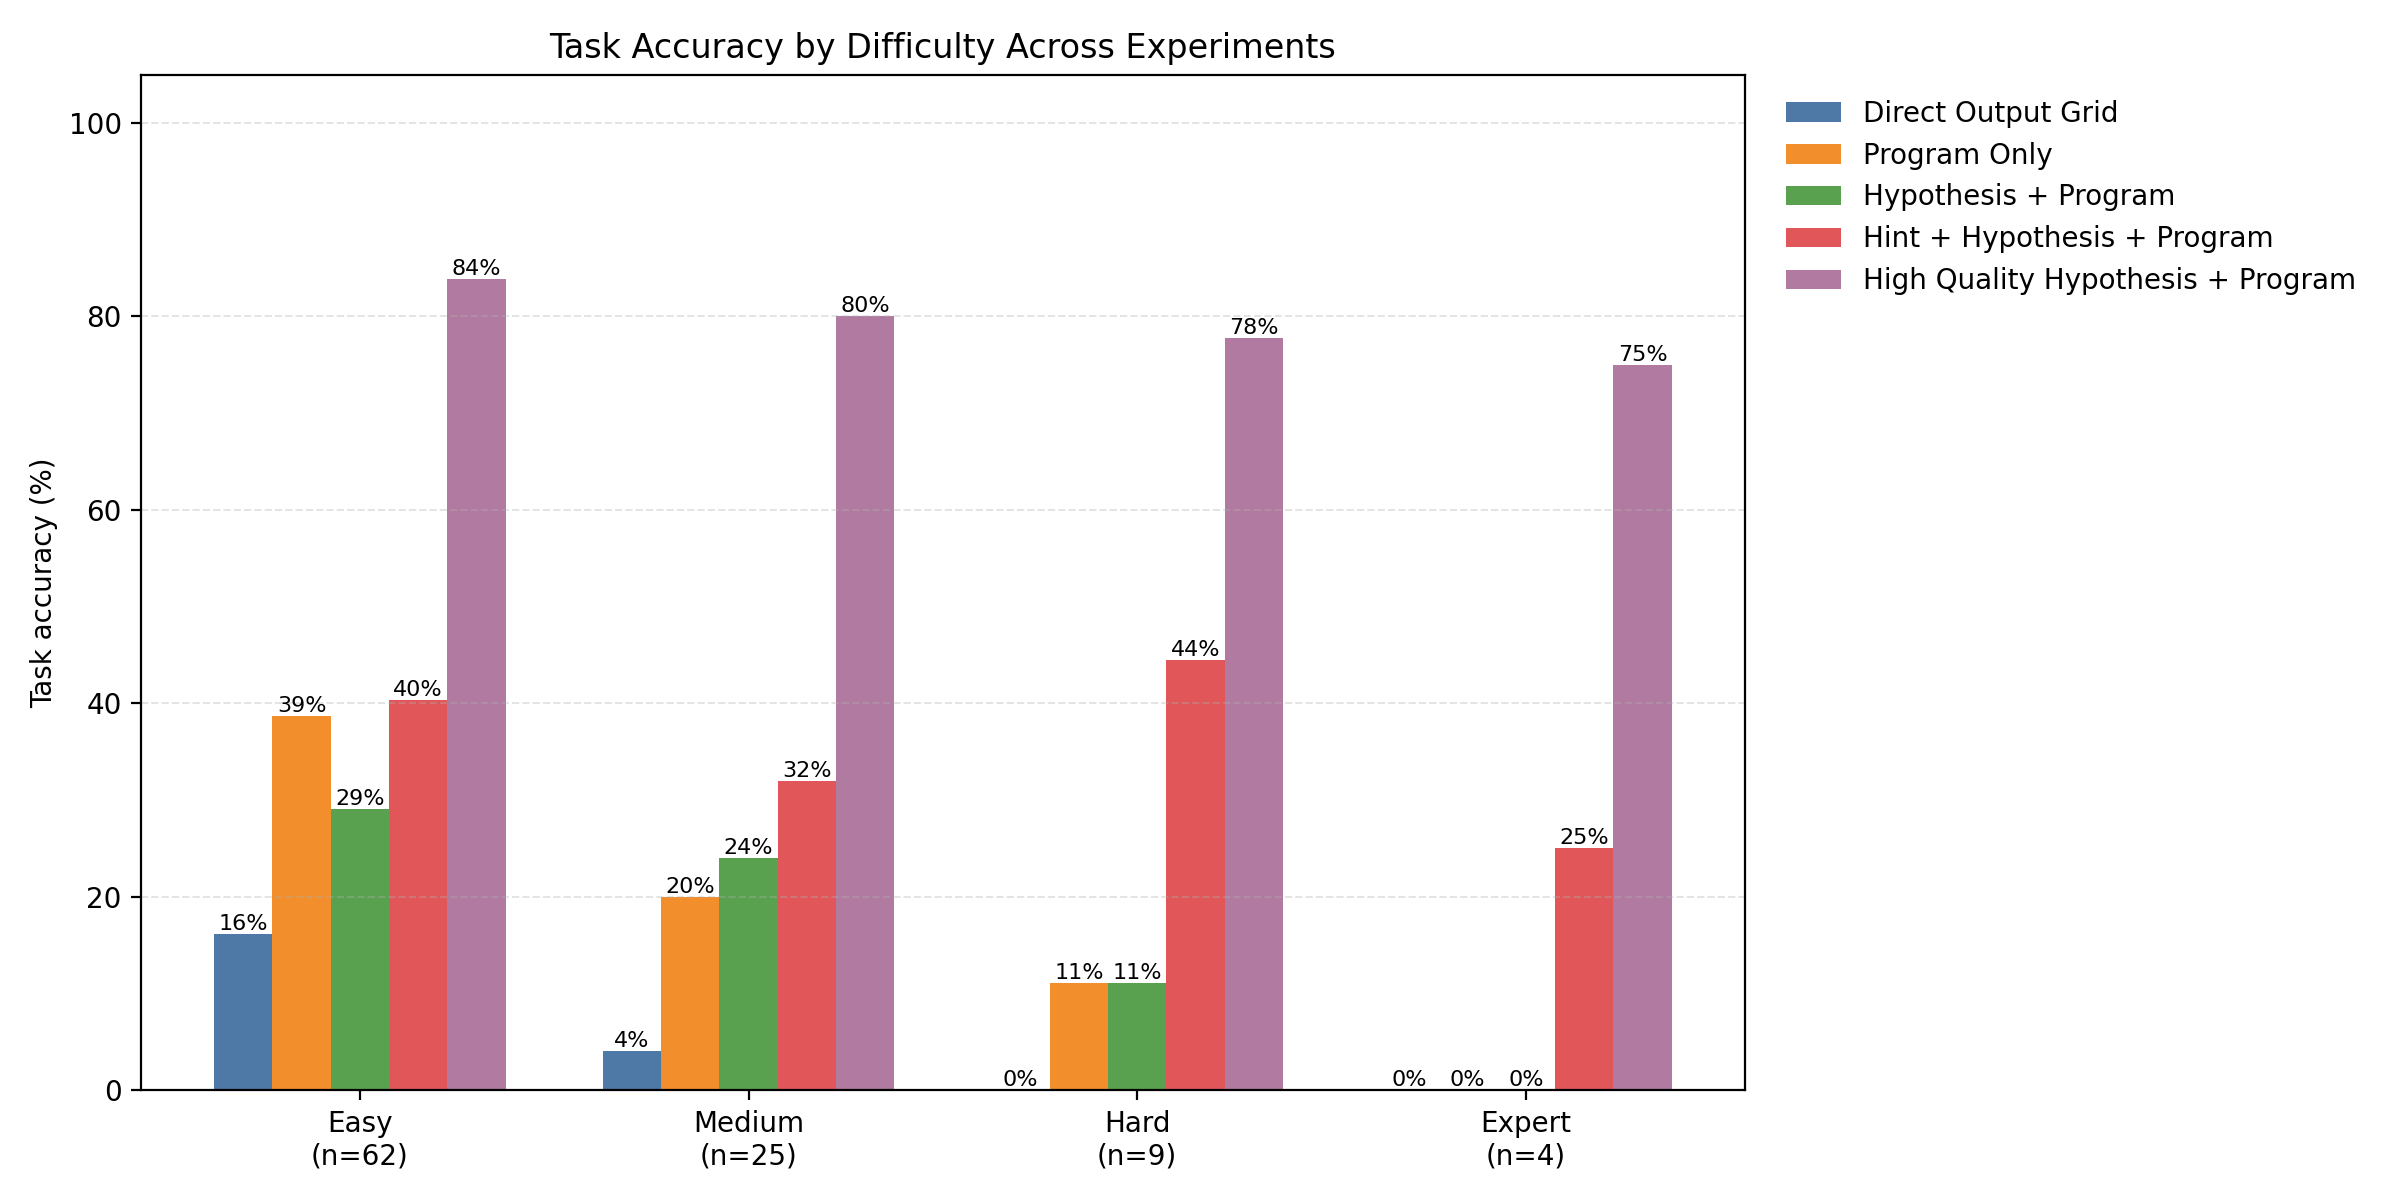

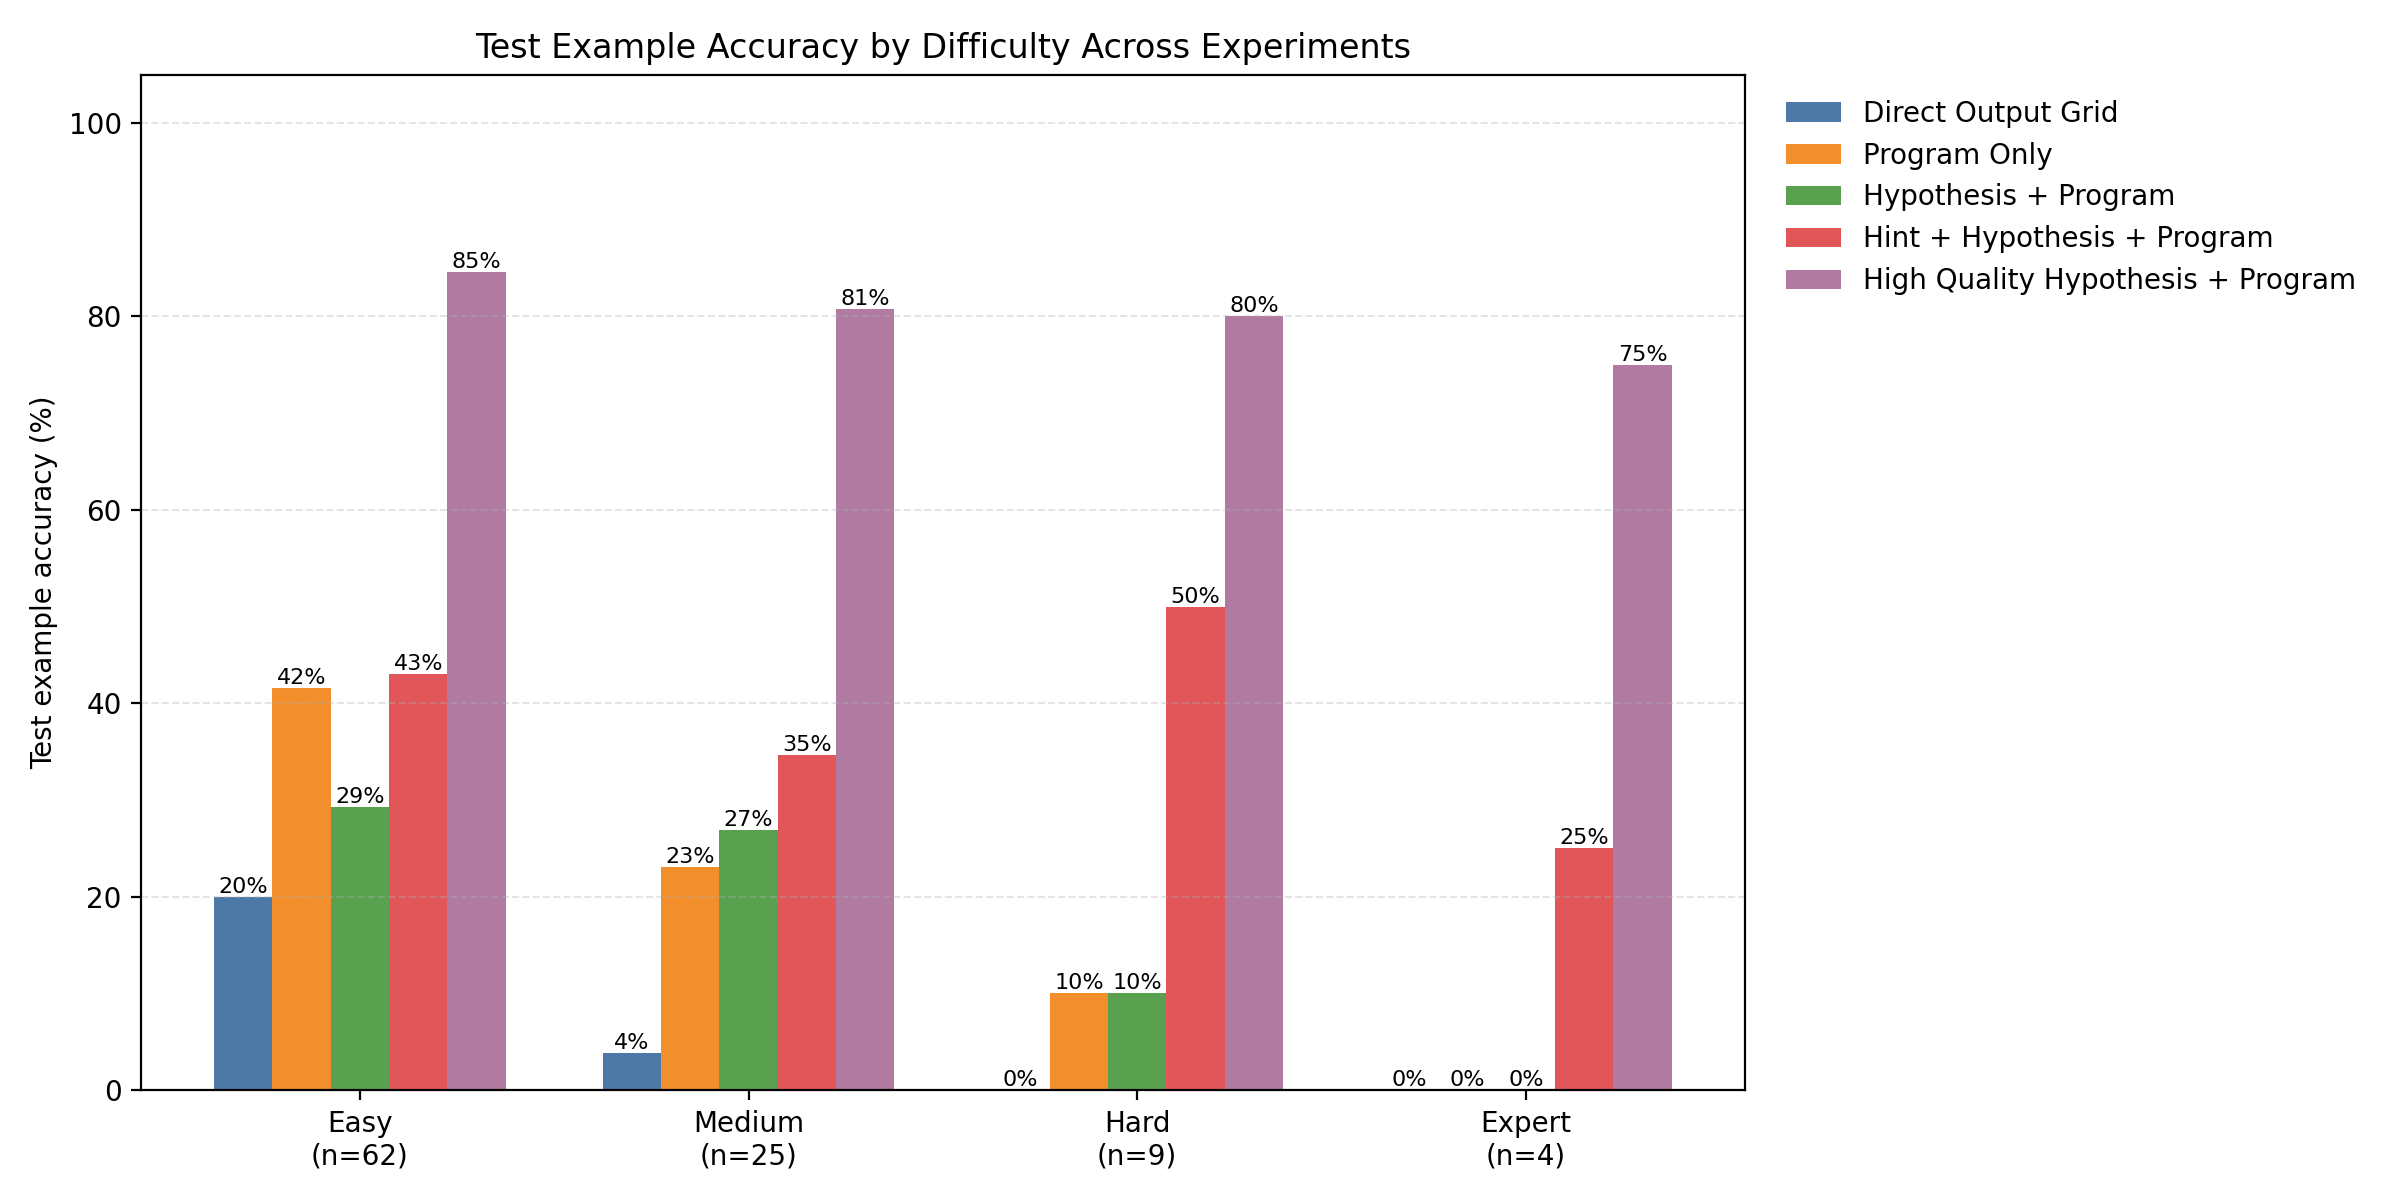

In [19]:
task_fig = OUTPUT_DIR / "task_accuracy_by_difficulty.png"
example_fig = OUTPUT_DIR / "example_accuracy_by_difficulty.png"
plot_grouped_bars(summary, "task_accuracy", "Task accuracy (%)", "Task Accuracy by Difficulty Across Experiments", task_fig)
plot_grouped_bars(summary, "example_accuracy", "Test example accuracy (%)", "Test Example Accuracy by Difficulty Across Experiments", example_fig)
display(DisplayImage(filename=str(task_fig)))
display(DisplayImage(filename=str(example_fig)))